In [165]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set plotting style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Random seed
RANDOM_STATE = 42

## Load the data

In [168]:
# Load dataset
df = pd.read_csv("../data/raw/Telco_customer_churn.csv")

# Display first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [170]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [174]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [176]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [178]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [180]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [182]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [184]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [186]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Missing values 

In [189]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
customerID,0,0.0
DeviceProtection,0,0.0
TotalCharges,0,0.0
MonthlyCharges,0,0.0
PaymentMethod,0,0.0
PaperlessBilling,0,0.0
Contract,0,0.0
StreamingMovies,0,0.0
StreamingTV,0,0.0
TechSupport,0,0.0


## Duplicate Rows

In [192]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## Unique Values

In [195]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

customerID: 7043
gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
tenure: 73
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
MonthlyCharges: 1585
TotalCharges: 6531
Churn: 2


## Target value distribution

In [198]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


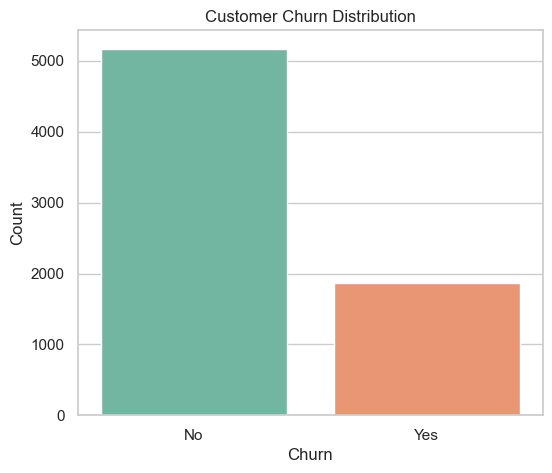

In [200]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

## churn Percentage

In [203]:
churn_percent = (
    df["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(churn_percent)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## Numerical and Categorical Features

In [206]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features")
print(categorical_cols)

print("\nNumerical Features")
print(numerical_cols)

Categorical Features
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges']


## Save Raw Information

In [209]:
df.to_csv("../data/processed/raw_loaded.csv", index=False)

In [211]:
# Check for blank strings in TotalCharges
(df["TotalCharges"] == " ").sum()

11

## Pie chart

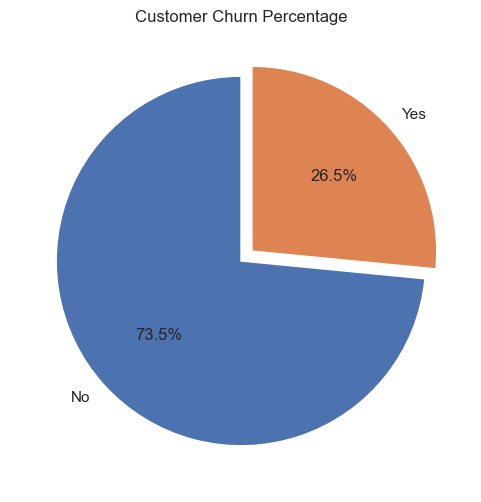

In [214]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    explode=[0,0.08]
)

plt.ylabel("")
plt.title("Customer Churn Percentage")
plt.show()

## Separate Numerical and Categorical Features

In [217]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:", categorical_cols)
print("\nNumerical Features:", numerical_cols)

Categorical Features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


## Numerical Summary

In [220]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## Histograms

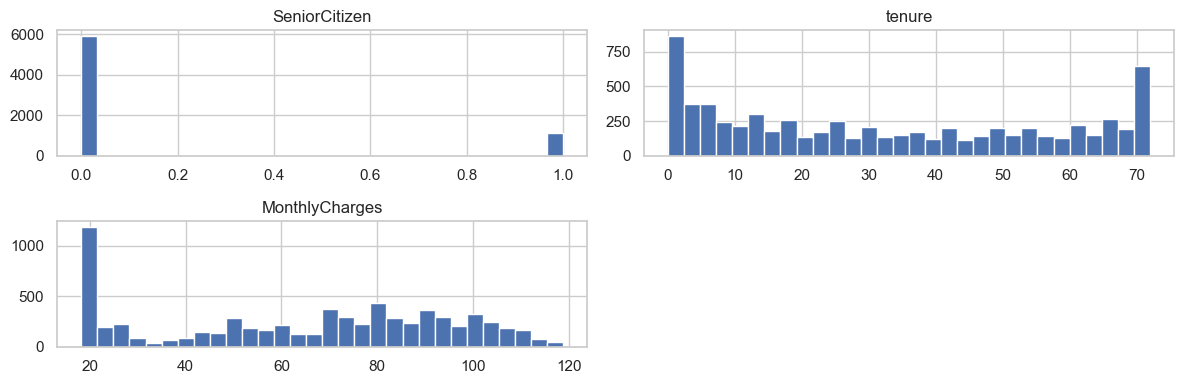

In [223]:
df[numerical_cols].hist(
    figsize=(12,4),
    bins=30
)

plt.tight_layout()
plt.show()

## Boxplots

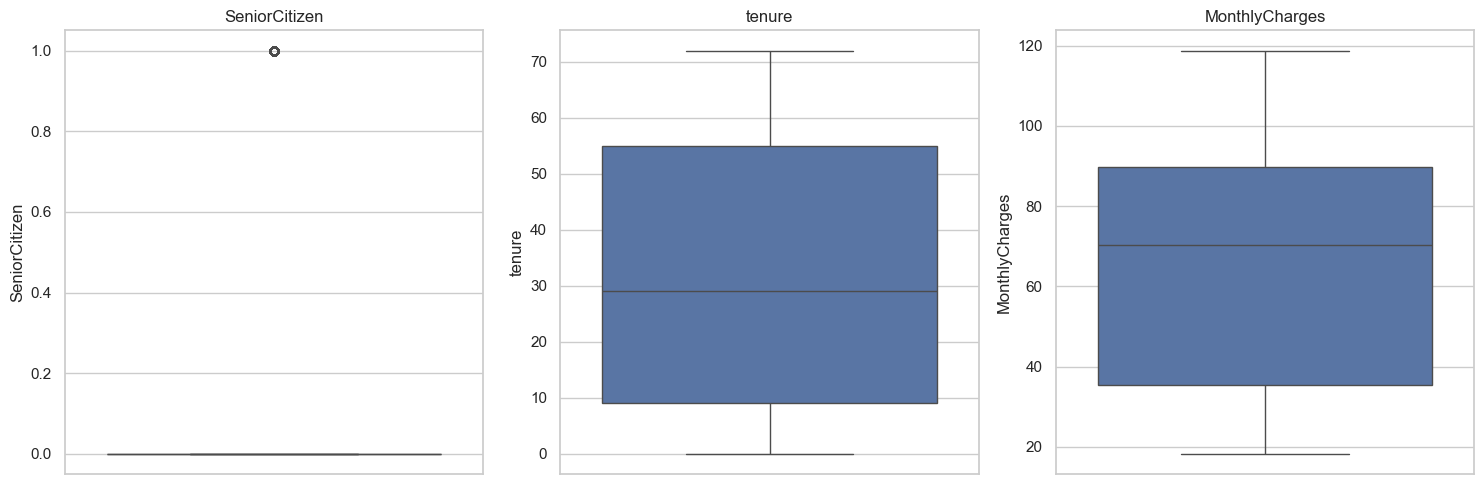

In [226]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15,5))

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(
        y=df[col],
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [281]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values again
df["TotalCharges"].isnull().sum()

11

## Churn vs Numerical Features

### Tenure 

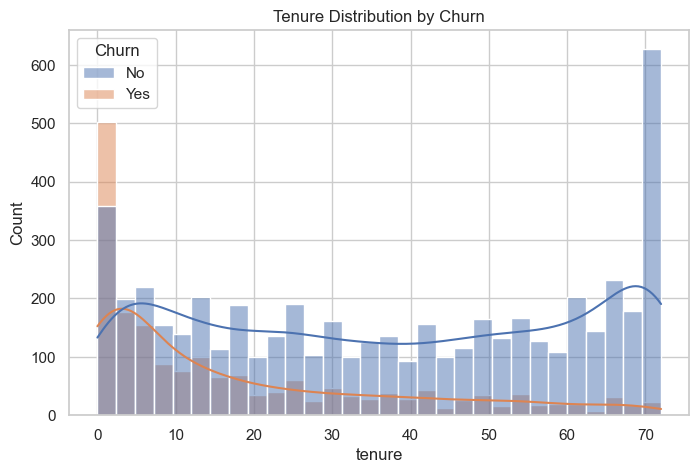

In [262]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.show()

### Monthly charges

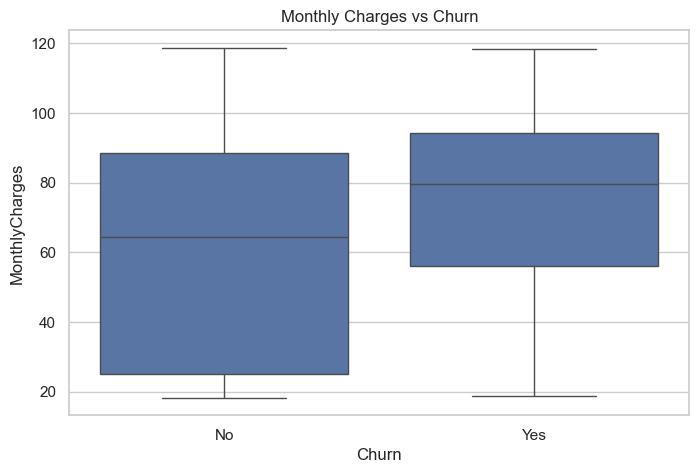

In [266]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

### Total charges 

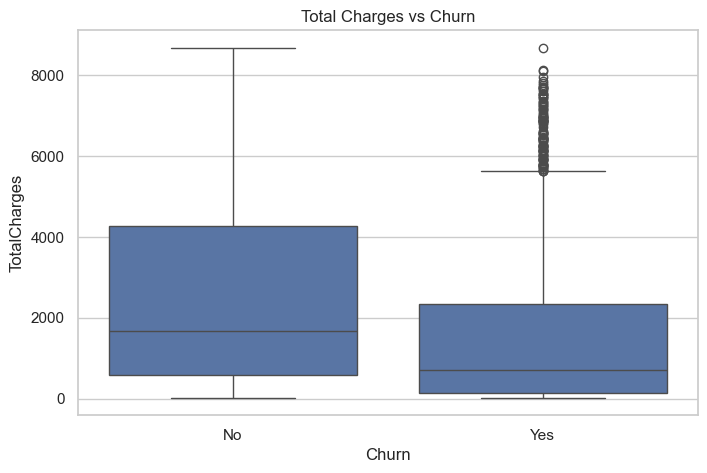

In [269]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.show()

## categorical feature vs churn

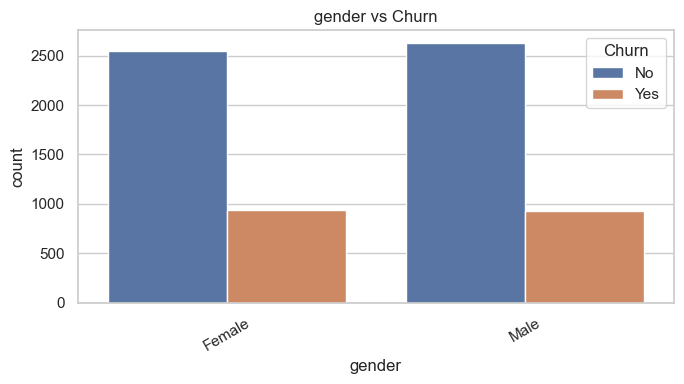

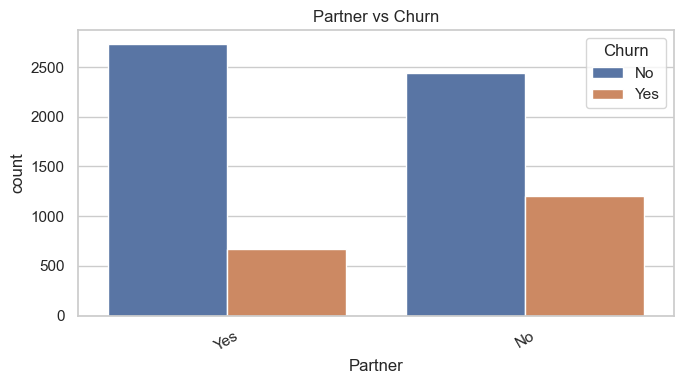

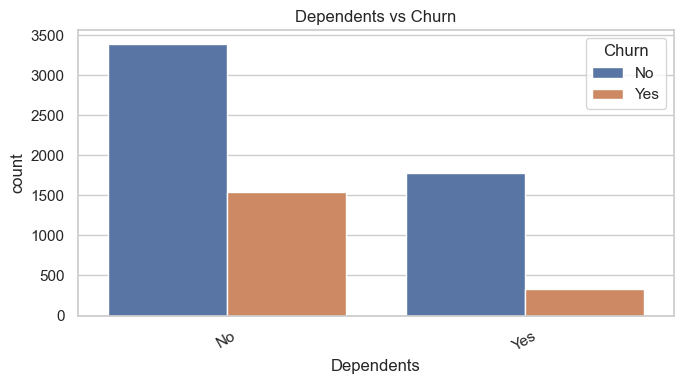

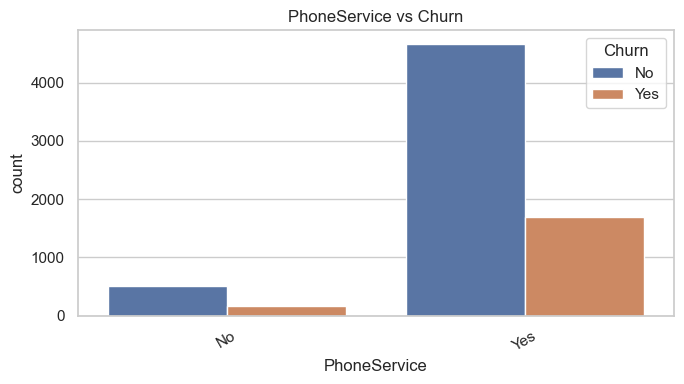

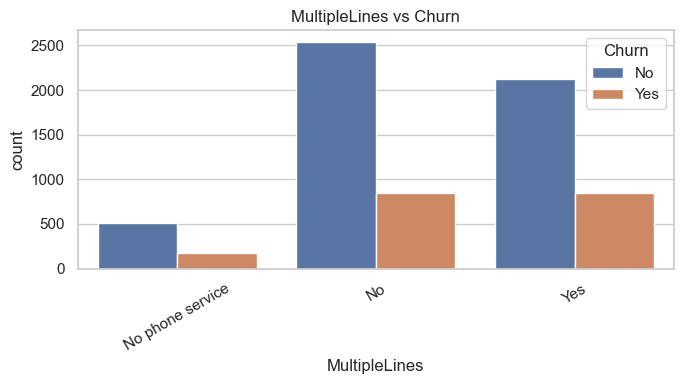

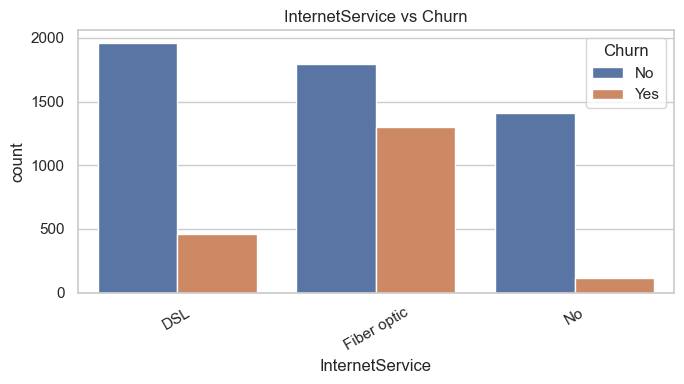

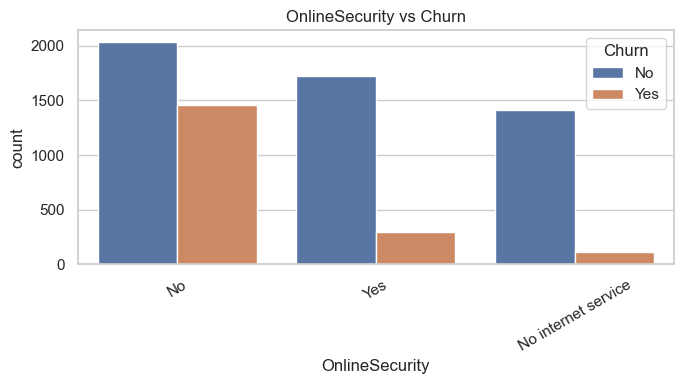

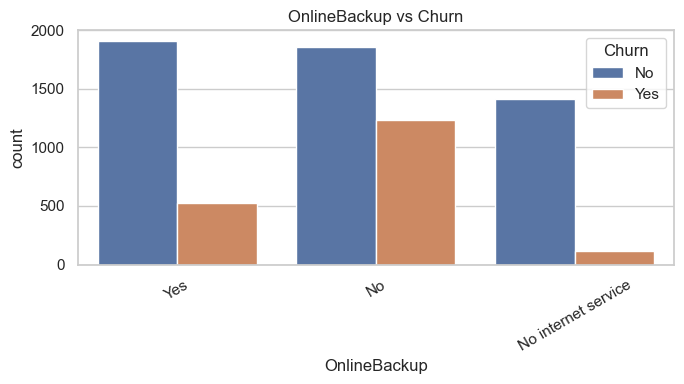

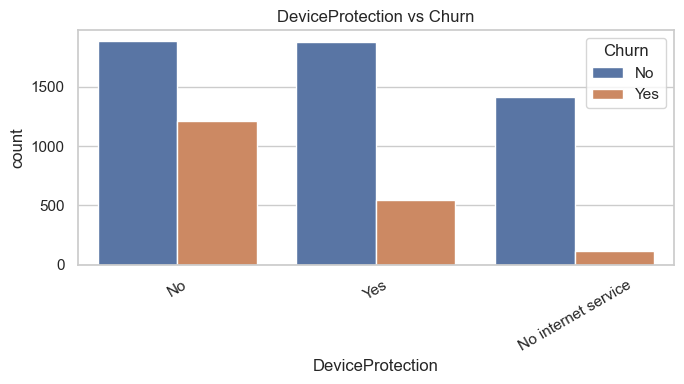

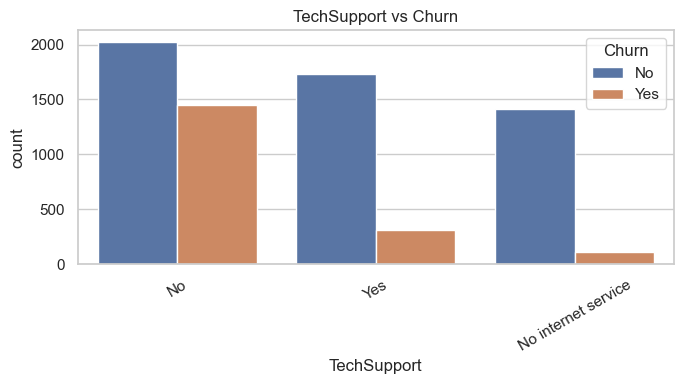

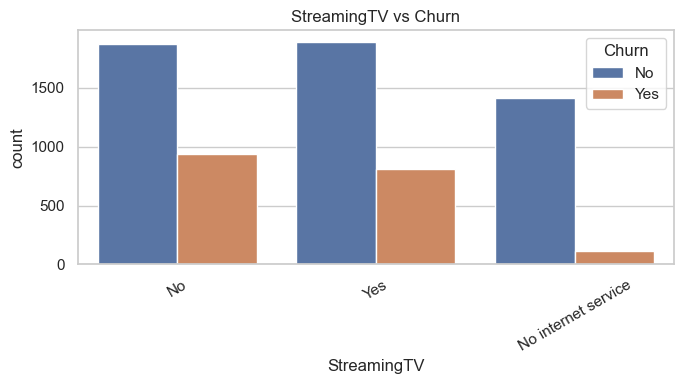

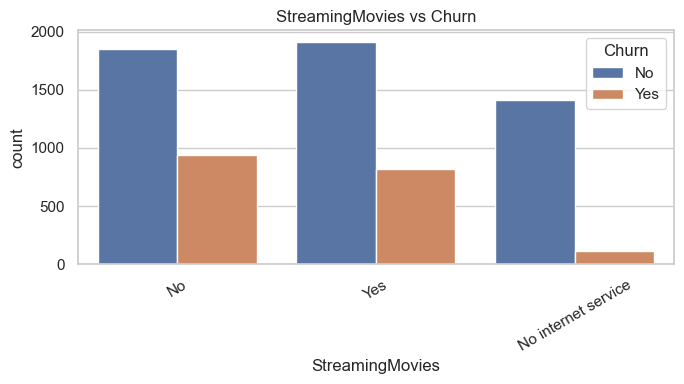

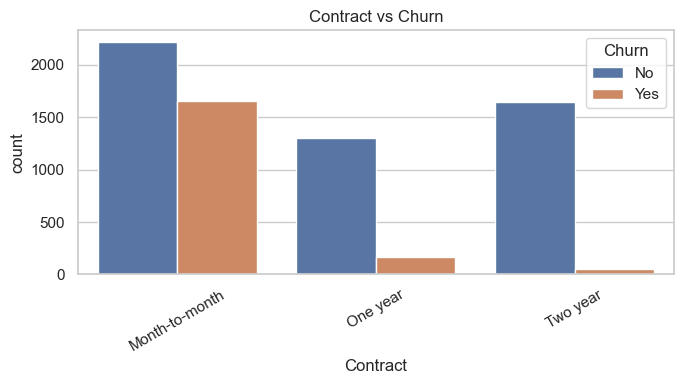

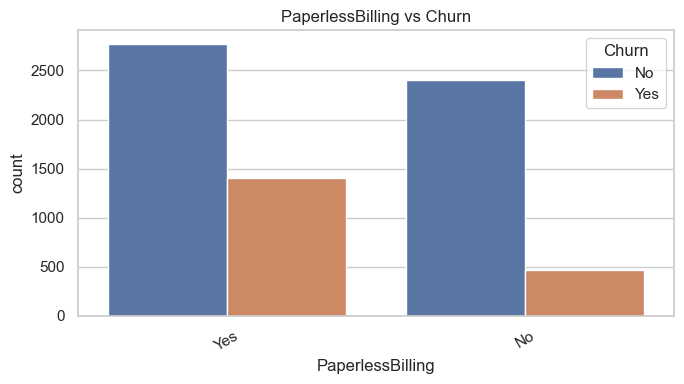

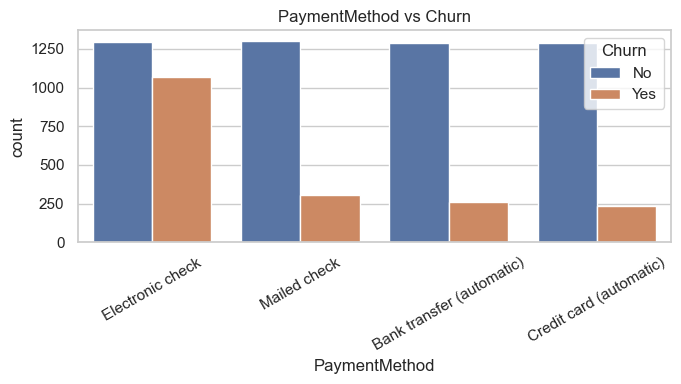

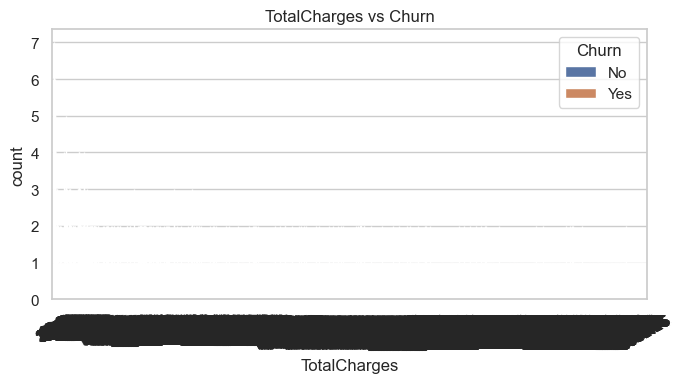

In [272]:
categorical_features = [
    col for col in categorical_cols
    if col not in ["customerID", "Churn"]
]

for col in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Churn"
    )

    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Churn Rate by Category (Much More Useful)

In [274]:
for col in categorical_features:

    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    print(f"\n{'='*50}")
    print(col)
    print(churn_rate.round(2))


gender
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

Partner
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66

Dependents
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

PhoneService
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71

MultipleLines
Churn                No    Yes
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

InternetService
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

OnlineSecurity
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61

OnlineBackup
Churn                   No    Yes
Online

## Correlation Matrix

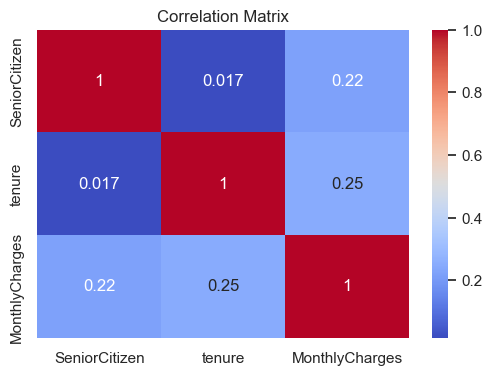

In [276]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Missing value visualization

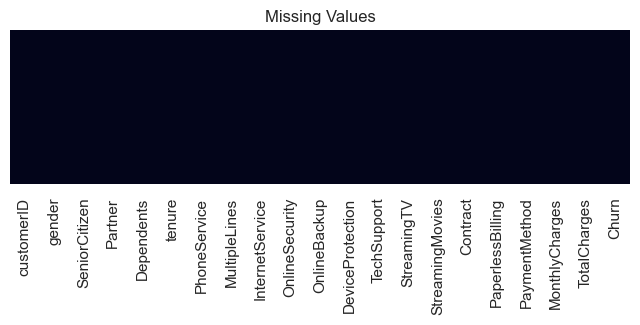

In [278]:
plt.figure(figsize=(8,2))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values")
plt.show()

### Key EDA Insights

• The dataset contains 7,043 customers and 21 features.
• No duplicate records were found.
• TotalCharges was stored as an object because of blank values and needs conversion to numeric.
• The target variable is imbalanced:
    - No Churn: ~73%
    - Churn: ~27%
• Customers with month-to-month contracts exhibit a higher churn rate.
• Customers using Fiber Optic internet appear to churn more frequently.
• Customers without Online Security and Tech Support are more likely to churn.
• Customers with shorter tenure show a higher tendency to churn.
• Higher monthly charges are associated with increased churn.